In [1]:
import os, sys
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"

GMFLOW = os.path.join("submodules", "GMFlow")
sys.path.insert(0, GMFLOW)

In [2]:
from backbones.gmdit import GMDiT

# 사용 예
model = GMDiT()
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv-full`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '
2025-09-22 11:47:30.689046: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/logpx_samplers/submodules/GMFlow/lib/ops/gmflow_ops/gmflow_ops.py:31: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

cannot get type annotation for Parameter scheduler of <class 'lib.pipelines.gmdit_pipeline.GMDiTPipeline'>.


Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

Expected types for id2label: (typing.Dict[int, str], <class 'NoneType'>), got typing.Dict[str, str].


In [14]:
!ls 

backbones  fid		   paper		   runs		 toy
clip	   figs		   prompts		   samplings	 training
command    huggingface	   README.md		   sh		 utils
datasets   LICENSE	   reports		   simple_euler
edm	   logs		   requirements_gmdit.txt  solvers
example    mscoco2014_fid  requirements.txt	   submodules


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

save = True
def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title="", number=0):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1, 3):  # CHW -> HWC
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if n == 0:
        return

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image), dpi=30)
    if n == 1:
        axes = [axes]

    # 여백 완전 제거
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

    # 제목이 있더라도 레이아웃 안 밀리게
    if display_title:
        fig.text(0.5, 0.995, display_title, ha='center', va='top', fontsize=10)

    for ax, img_arr in zip(axes, processed):
        ax.imshow(img_arr)
        ax.set_axis_off()  # 축/테두리/눈금 모두 제거

    if save:
        fig.savefig(f"figs/which{number}.png", bbox_inches='tight', pad_inches=0)        

    plt.margins(0, 0)
    plt.show()


0


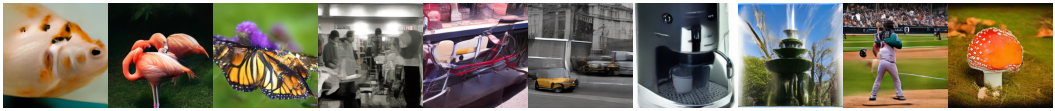

1


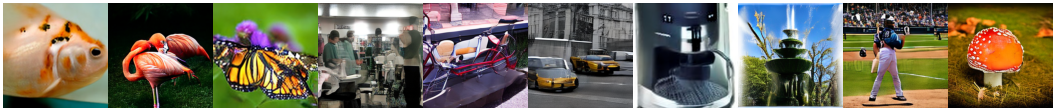

2


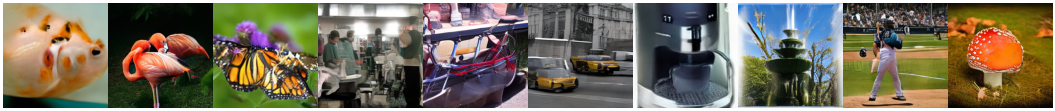

3


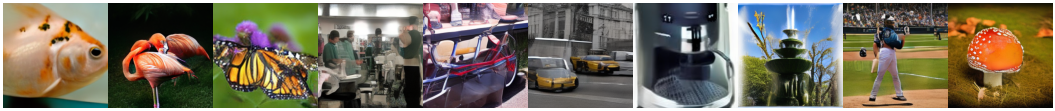

4


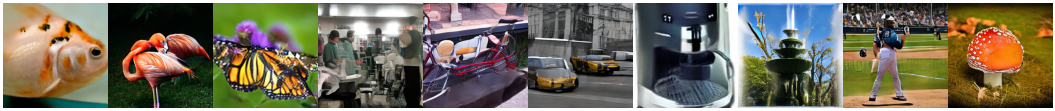

5


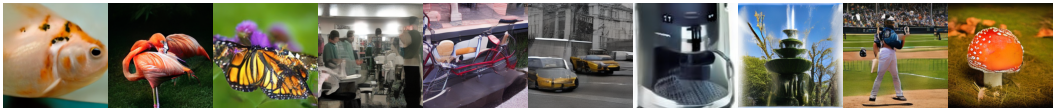

6


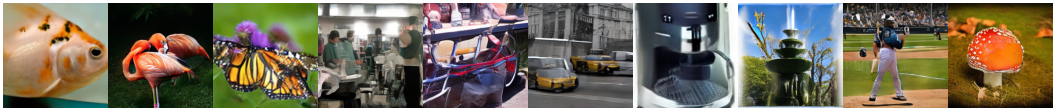

7


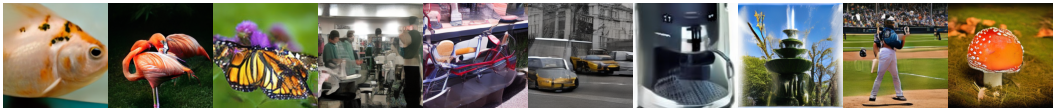

8


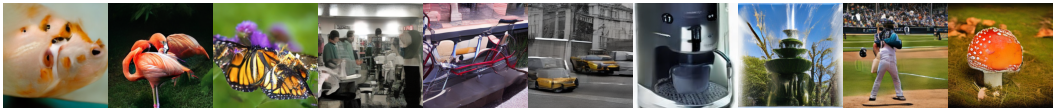

9


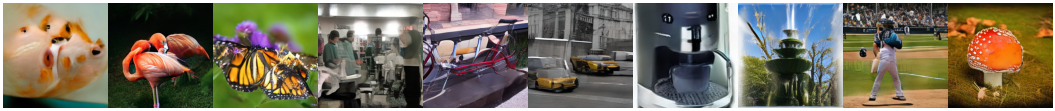

10


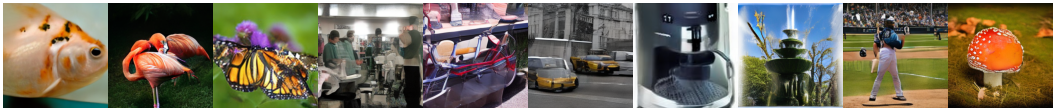

11


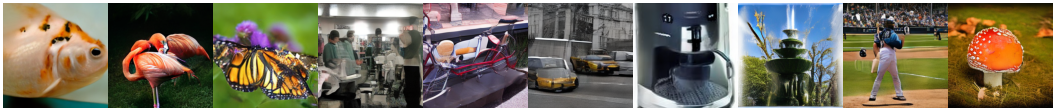

12


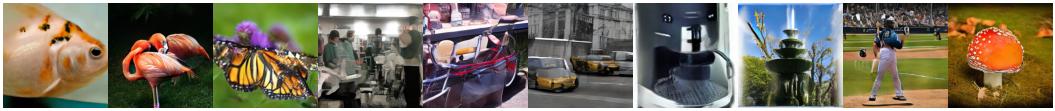

13


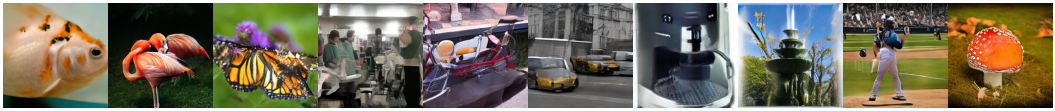

14


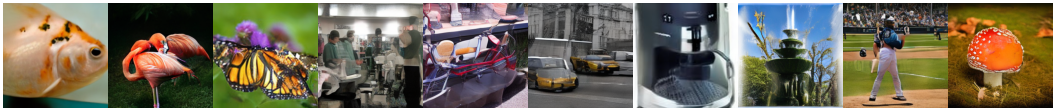

15


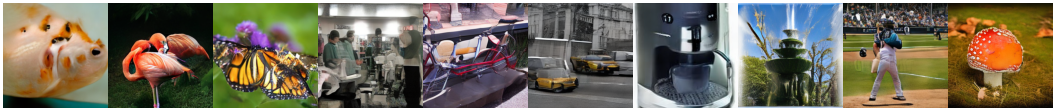

16


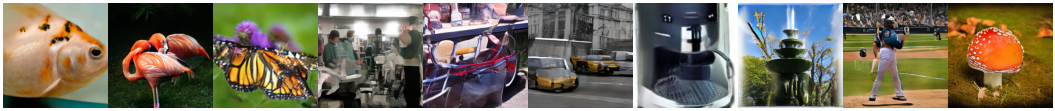

17


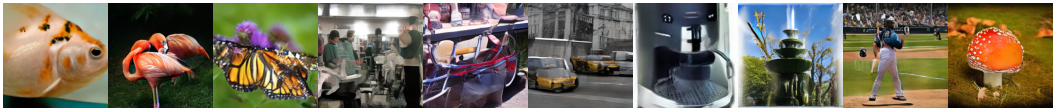

18


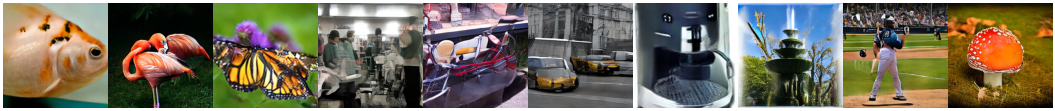

19


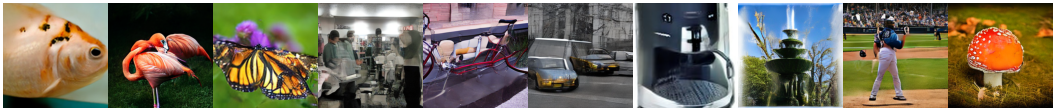

In [13]:
import numpy as np
from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor
import torch
from utils.util import get_pt

# 클래스 0–9로 설정
class_ids = [1, 130, 323, 424, 444, 468, 550, 562, 981, 992]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=1.5)
noises = model.get_noise(seeds=class_ids)

NFE = 3

extractor = Extractor(steps=NFE)
transform = LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2)
solver = GDual_Solver(
    noise_schedule,
    steps=NFE,
    transform=transform,
    param_extractor=extractor,
    skip_type="time_uniform_flow",
    pred_order=1,
    corr_order=2,
    order1_kappa=True,
    order2_kappa=True,
    use_corrector=True,
    time_learning=True,
    train_mode=True
).to(model.device)

for n in range(20):
    print(n)
    pt_file = get_pt(f'logs/gmdit/which/s{NFE}_n{n}', 'latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    solver.load_state_dict(state_dict, strict=True)
    with torch.no_grad():
        latents = solver.sample(noises, model_fn)['samples']
        samples = model.decode_vae(latents, pil_output=True)['pil_output']
    display_class_images(samples, class_ids, display_title='Dual', number=n)


In [12]:
print('done')